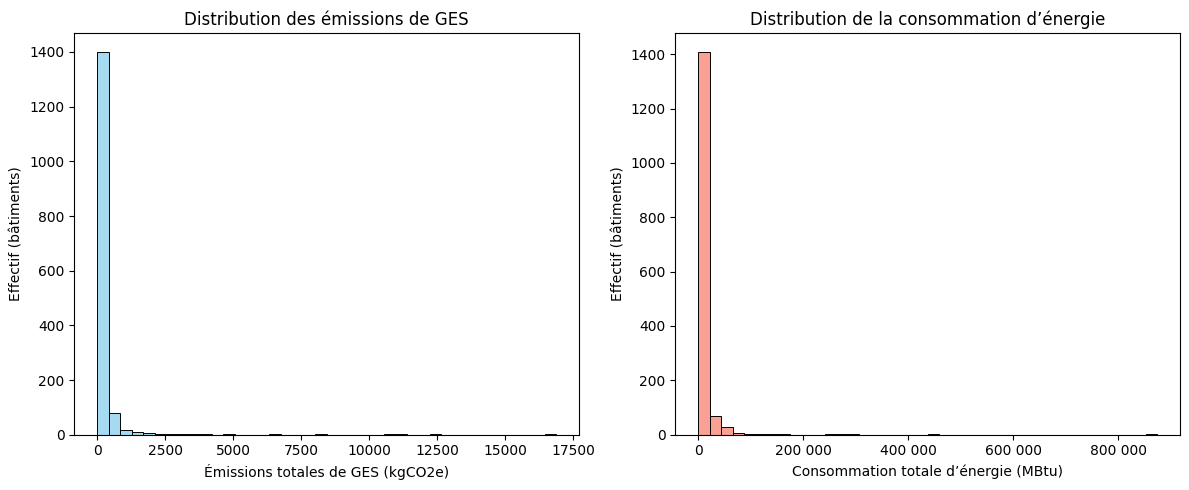

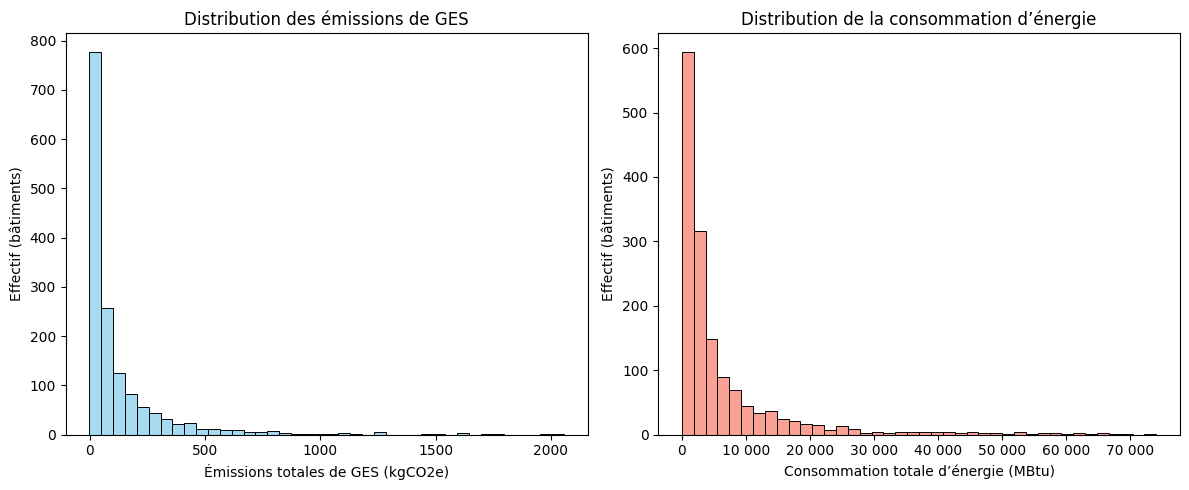

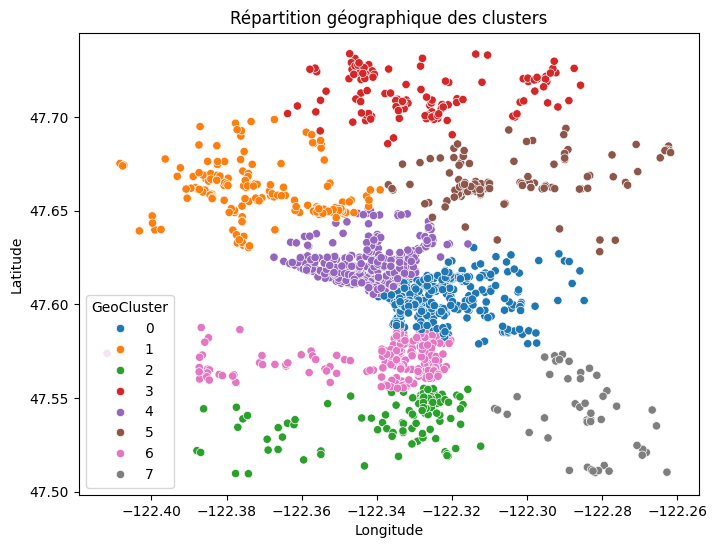

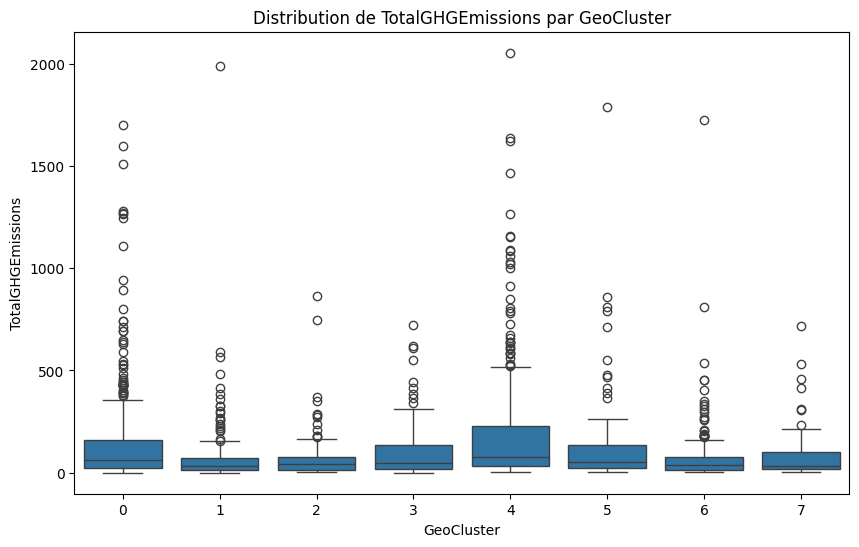

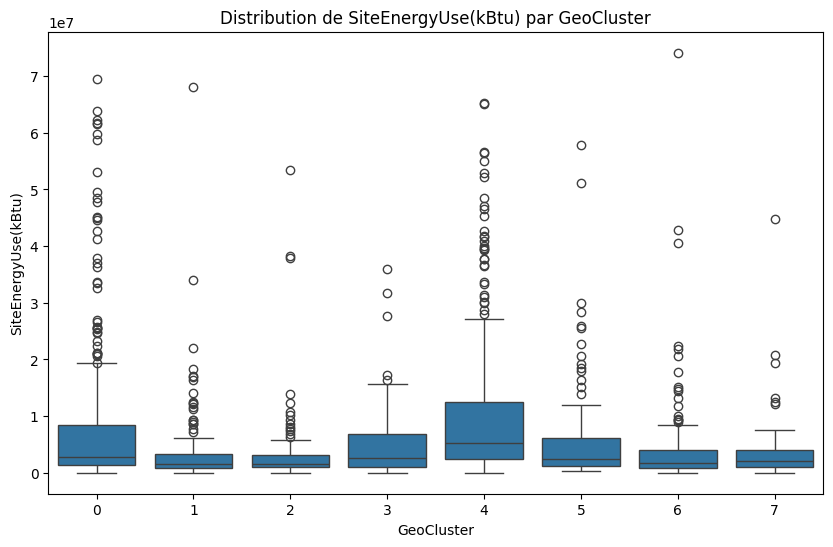

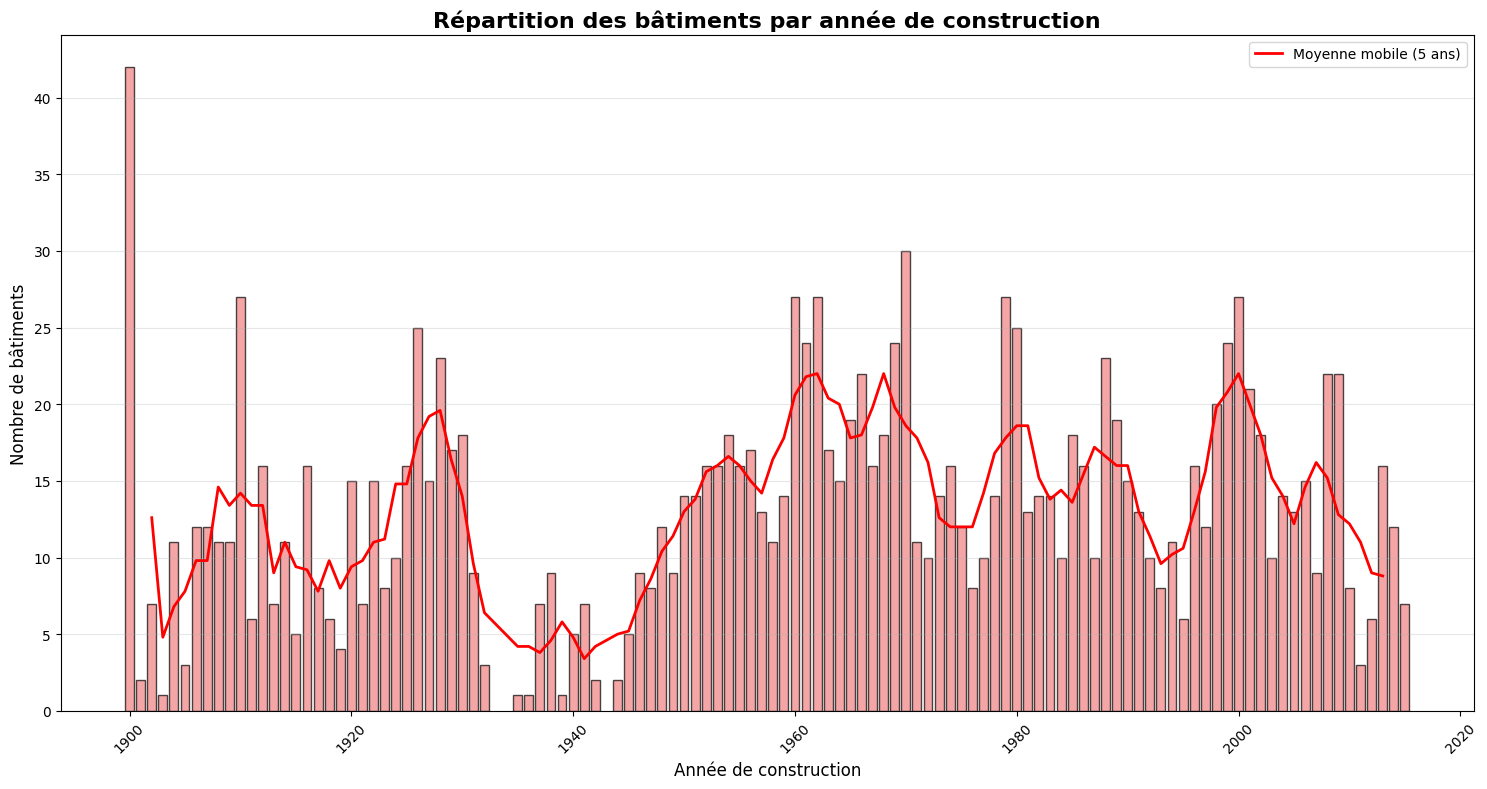

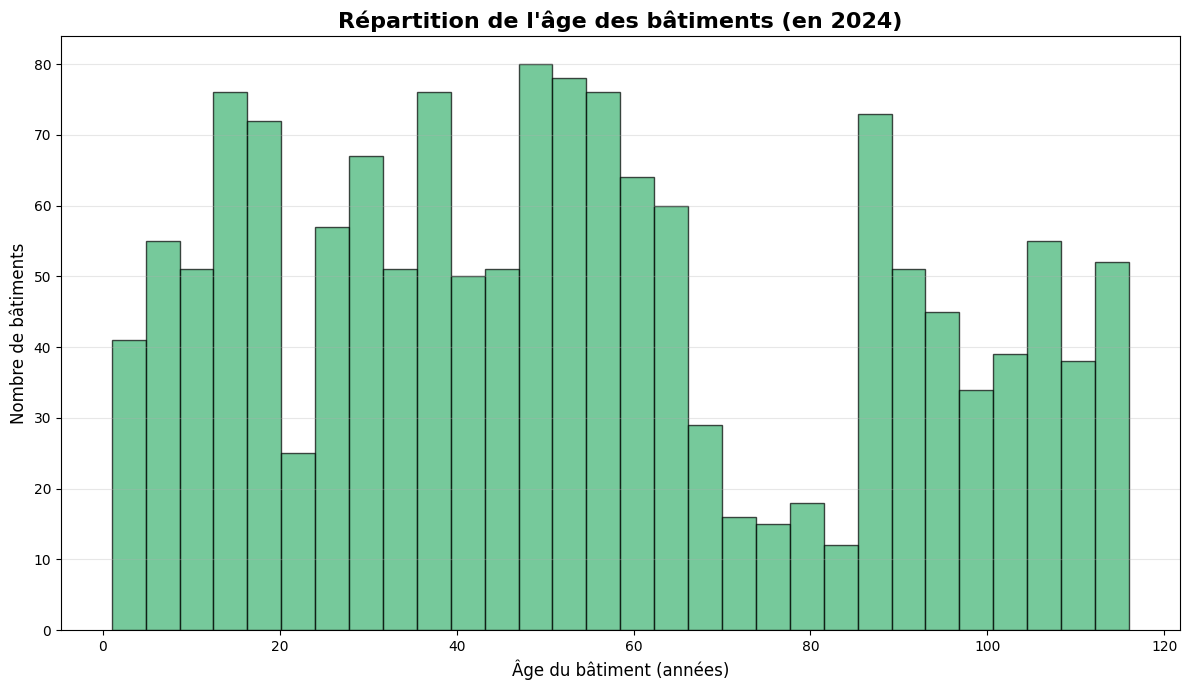

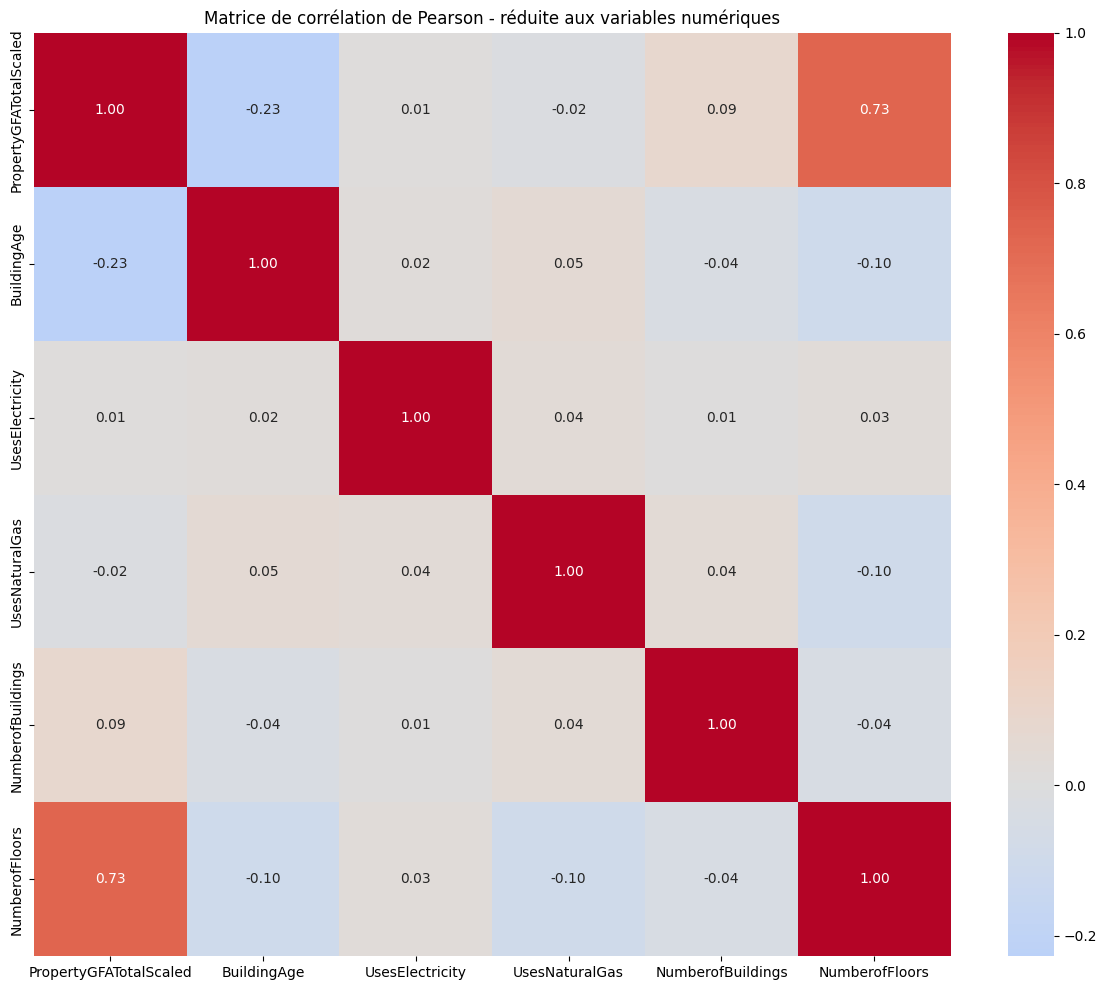

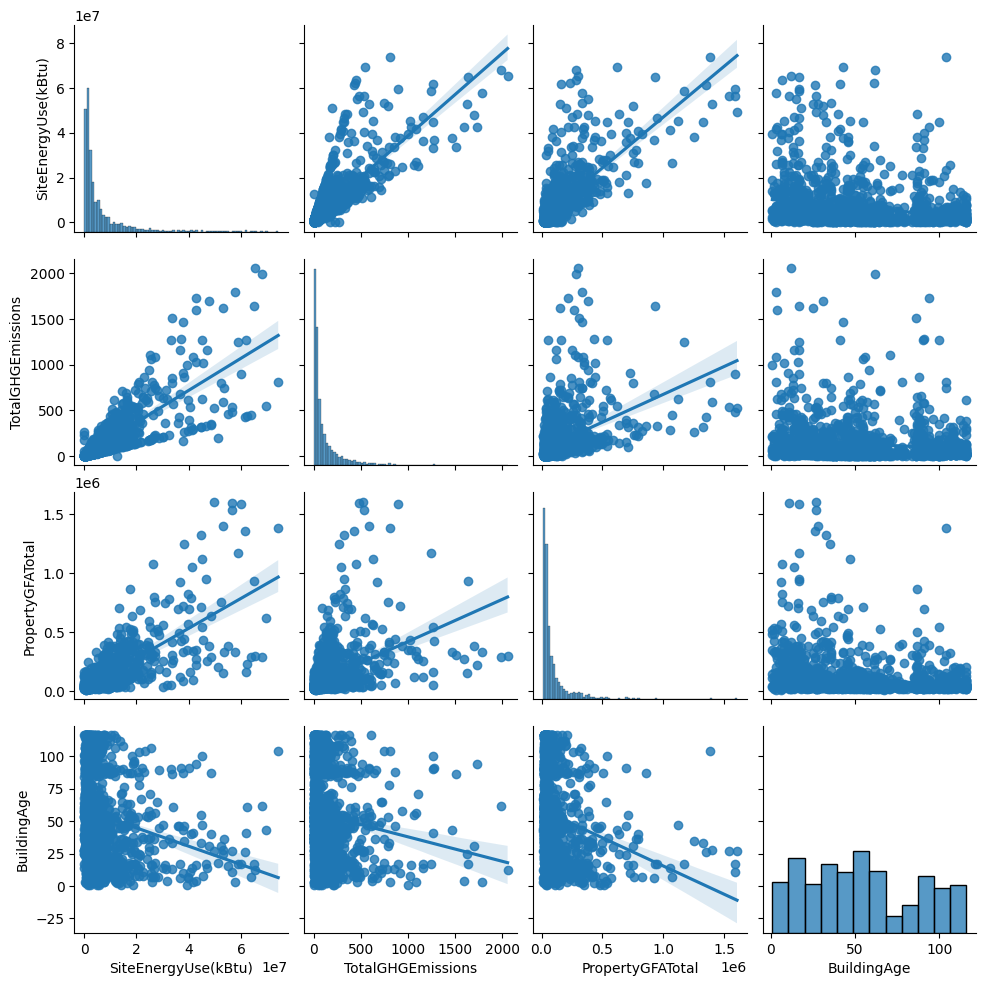

In [1]:
# On exécute le précédent notebook car on est dépendant des résultats
import sys
import os
from contextlib import redirect_stdout, redirect_stderr

# Désactiver l'affichage AVANT d'importer matplotlib
%matplotlib agg

with open(os.devnull, 'w') as fnull:
    with redirect_stdout(fnull), redirect_stderr(fnull):
        %run 2+3_feature-engineering.ipynb

# FORCER la réactivation de l'affichage
%matplotlib inline

# Réinitialiser matplotlib pour forcer le nouveau backend
import matplotlib
matplotlib.pyplot.close('all')  # Fermer toutes les figures existantes

# Modèles pour prédire la consommation en énergie
## Régression linéaire

MSE: 1.2423671822682705
RMSE: 1.1146152619932452
MAE: 0.7991684399828466
MAPE: 335793142745597.4
R²: 0.5501224825500484
          réel    prédit
669   6.852502  6.883974
2163  7.383918  7.950736
437   7.844641  7.175770
684   5.914291  6.683189
1727  5.792339  7.540263
2227  6.901531  7.030824
223   7.515783  7.603189
2050  7.523120  8.077727
1058  8.072681  7.953752
2086  6.399455  8.177770
3160  9.096918  9.413442
2447  5.822292  7.338290
363   6.666148  7.588940
1436  7.815629  6.665360
1214  6.126767  7.781594
2789  7.810799  7.751383
773   7.065096  8.126231
1583  6.153796  7.219877
535   7.954835  6.775550
1783  8.545857  8.115682


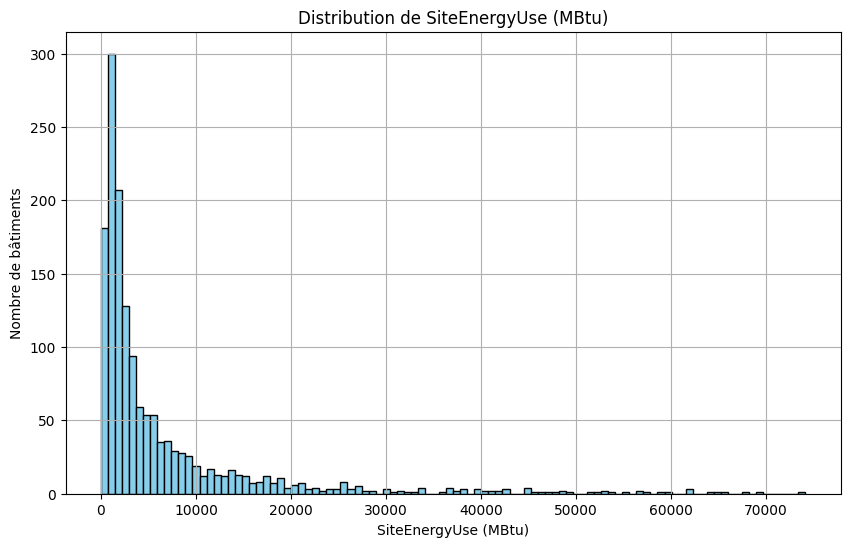

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score, mean_absolute_error

# on fixe un random_state pour la reproductibilité des résultats
random_state = 42

# les variables prédictives
X = df_selected

# Première variable cible : énergie totale utilisée
y = np.log1p(df['SiteEnergyUse(MBtu)'])

# on choisit un modèle de régression linéaire
reg = LinearRegression()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=random_state)

reg.fit(X_train, y_train)
y_pred_test = reg.predict(X_test)

print(f"MSE: {mean_squared_error(y_test, y_pred_test)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test))}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_test)}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred_test)}")
print(f"R²: {r2_score(y_test, y_pred_test)}")

comparaison = pd.DataFrame({'réel': y_test, 'prédit': y_pred_test})
print(comparaison.head(20))

plt.figure(figsize=(10,6))
plt.hist(df['SiteEnergyUse(MBtu)'], bins=100, color='skyblue', edgecolor='black')
plt.xlabel('SiteEnergyUse (MBtu)')
plt.ylabel('Nombre de bâtiments')
plt.title('Distribution de SiteEnergyUse (MBtu)')
plt.grid(True)
plt.show()

### Validation croisée

On réeffectue la régression linéaire avec une validation croisée cross_validate.

On crée une fonction qui permet de faire une validation croisée et afficher les résultats pour tous nos autres modèles

In [3]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LinearRegression

# Fonction pour la validation croisée de modèles et affichage des résultats
def cross_validate_and_print_results(reg, X, y):
    cv_results = cross_validate(
        reg, 
        X, 
        y, 
        cv=5,  # nombre de folds (par défaut 5)
        scoring=['neg_mean_squared_error', 'r2', 'neg_mean_absolute_error', 'neg_mean_absolute_percentage_error'],
        return_train_score=False
    )

    # Calcul des métriques
    mse_mean = -cv_results['test_neg_mean_squared_error'].mean()
    rmse_mean = np.sqrt(mse_mean)
    mae_mean = -cv_results['test_neg_mean_absolute_error'].mean()
    mape_mean = -cv_results['test_neg_mean_absolute_percentage_error'].mean()
    r2_mean = cv_results['test_r2'].mean()
    
    # Création du tableau
    results_df = pd.DataFrame({
        'Métrique': ['MSE', 'RMSE', 'MAE', 'MAPE (%)', 'R²'],
        'Moyenne': [
            f"{mse_mean:,.0f}",
            f"{rmse_mean:,.1f}",
            f"{mae_mean:,.1f}",
            f"{mape_mean*100:.2f}",
            f"{r2_mean:.4f}"
        ]
    })

    styled_table = (
        results_df.style
        .set_caption("Résultats Validation Croisée")
        .hide(axis="index")
        .set_properties(**{'text-align': 'left'})
        .set_table_styles(
            [
                {"selector": "th", "props": [("text-align", "left")]},
                {"selector": "td", "props": [("min-width", "200px")]}
            ]
        )
    )

    display(styled_table)
# Modèle
reg = LinearRegression()

# Validation croisée
cross_validate_and_print_results(reg, X, y)


Métrique,Moyenne
MSE,1
RMSE,1.1
MAE,0.8
MAPE (%),19640040330113380.00
R²,0.3239


**Remarque : on constate avec la validation croisée que le modèle semble moins performant que notre premier essai**

* RMSE et MAE moyens **proches** du premier essai
* MAPE moyen **plus élevé**
* **R² plus bas** : de ~0,63 on passe à ~0.48

### Bilan
On constate que la régression linéaire n'est pas adaptée pour prédire la consommation en énergie. On constate également que la distribution de cette variable sur les données statistiques existantes n'est pas linéaire

## RandomForestRegressor

In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

reg = RandomForestRegressor(n_estimators=100, random_state=random_state)

cross_validate_and_print_results(reg, X, y)

Métrique,Moyenne
MSE,1
RMSE,0.9
MAE,0.6
MAPE (%),16899429274719146.00
R²,0.5307


**Remarque : on constate un R² un peu meilleur, ainsi qu'une MAE et RMSE un peu meilleures également. Toutefois l'amélioration est faible avec ce modèle, il est difficile de conclure que ce modèle est meilleur**

## XGBoost (Extreme Gradient Boosting)

In [5]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

reg = GradientBoostingRegressor(n_estimators=100, random_state=random_state)

cross_validate_and_print_results(reg, X, y)

Métrique,Moyenne
MSE,1
RMSE,0.8
MAE,0.6
MAPE (%),13719561270231982.00
R²,0.5906


**Remarque : on constate un R² sensiblement meilleur, ainsi qu'une MAE et RMSE un peu meilleures**

# Modèles pour prédire les émissions de gaz à effet de serre

On va appliquer directement la validation croisée à nos modèles

## Régression linéaire

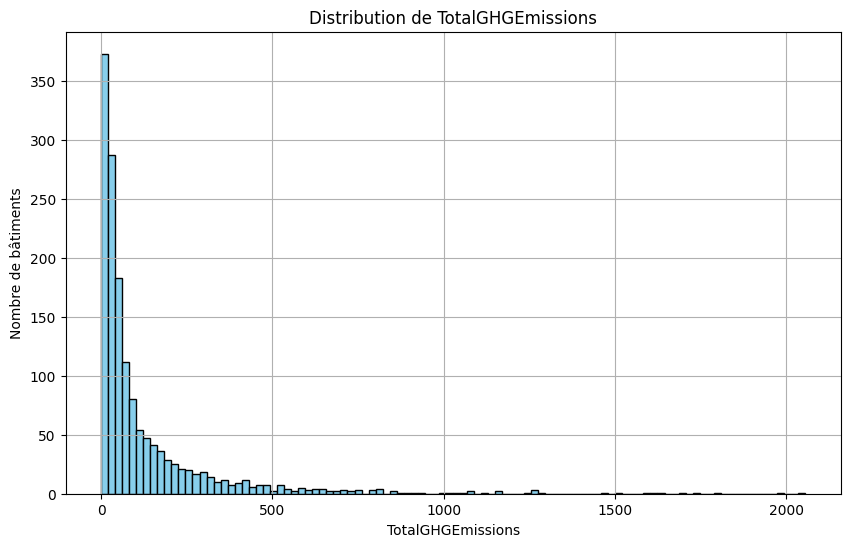

Métrique,Moyenne
MSE,"29,890"
RMSE,172.9
MAE,85.2
MAPE (%),98542341911186080.00
R²,0.3127


In [6]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LinearRegression

X = df_selected
y = df['TotalGHGEmissions']

plt.figure(figsize=(10,6))
plt.hist(df['TotalGHGEmissions'], bins=100, color='skyblue', edgecolor='black')
plt.xlabel('TotalGHGEmissions')
plt.ylabel('Nombre de bâtiments')
plt.title('Distribution de TotalGHGEmissions')
plt.grid(True)
plt.show()

cross_validate_and_print_results(reg, X, y)

### Bilan

On constate que la **régression linéaire** n'est pas adaptée (en l'état !) pour prédire les émissions de gaz à effet de serre.
On constate également que la distribution de cette variable sur les données statistiques existantes n'est **pas linéaire**